In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report

### Sigmoid

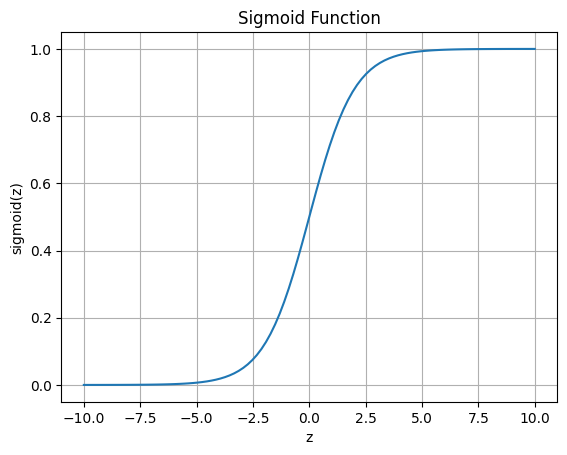

In [6]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

# Plotting
plt.plot(z, sigmoid_values)
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid()
plt.show()

### Exercise: Implement a Logistic Regression Model to Classify a Dataset 

In [17]:
# Generate synthetic data
np.random.seed(42)
n_samples = 200
X = np.random.rand(n_samples, 2) * 10
y = (X[:, 0] * 1.5 + X[:, 1] > 15).astype(int)  

# Create a DataFrame
df = pd.DataFrame(X, columns=['Age', 'Salary'])
df['Purchased'] = y

# Split Data
X_train, X_test, y_train, y_test = train_test_split(df[['Age', 'Salary']], df['Purchased'], test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



### Exercise 2: Analyze Model Performance

C:\Users\Helmy Krisdin Garcia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


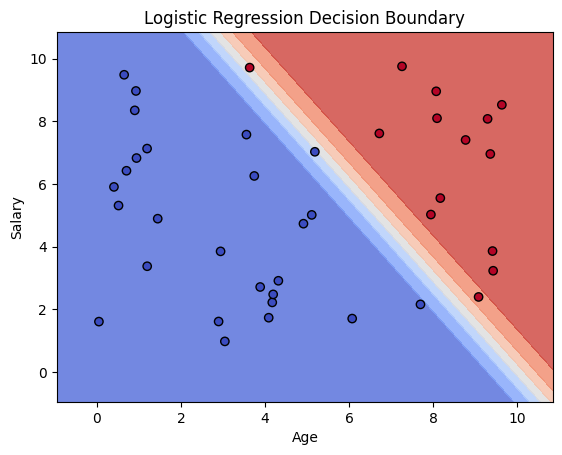

In [19]:
# Plot decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 0].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict probabilities for each point in the grid
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plotting
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test['Age'], X_test['Salary'], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()